In [1]:
!pip install -q sentence-transformers faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 87.4 MB/s eta 0:00:00:00:0100:01


In [2]:
import pandas as pd
import numpy as np
import faiss
import pickle

from tqdm import tqdm
from sentence_transformers import SentenceTransformer

In [3]:
import warnings, os
warnings.filterwarnings("ignore")
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [4]:
MEDQUAD_PATH = "/kaggle/input/datasets/pythonafroz/medquad-medical-question-answer-for-ai-research/medquad.csv"
DISEASE_PATH = "/kaggle/input/datasets/s3programmer/disease-diagnosis-dataset/disease_diagnosis.csv"


medquad = pd.read_csv(MEDQUAD_PATH)
disease_df = pd.read_csv(DISEASE_PATH)

print("MedQuAD Shape:", medquad.shape)
print("Disease Shape:", disease_df.shape)

print("\nMEDQUAD")
print(medquad.columns)

print("\nDISEASE")
print(disease_df.columns)

MedQuAD Shape: (16412, 4)
Disease Shape: (2000, 13)

MEDQUAD
Index(['question', 'answer', 'source', 'focus_area'], dtype='object')

DISEASE
Index(['Patient_ID', 'Age', 'Gender', 'Symptom_1', 'Symptom_2', 'Symptom_3',
       'Heart_Rate_bpm', 'Body_Temperature_C', 'Blood_Pressure_mmHg',
       'Oxygen_Saturation_%', 'Diagnosis', 'Severity', 'Treatment_Plan'],
      dtype='object')


In [5]:
medquad = medquad.fillna("")
medquad = medquad.drop_duplicates()

disease_df = disease_df.fillna("")
disease_df = disease_df.drop_duplicates()


In [6]:
medquad_docs = []

for _, row in medquad.iterrows():
    text = f"""
Question:
{row['question']}
Answer:
{row['answer']}
Medical Source:
{row['source']}
Focus Area:
{row['focus_area']}
"""
    medquad_docs.append(text)

print("MedQuAD Docs:", len(medquad_docs))



disease_docs = []
for _, row in disease_df.iterrows():
    text = f"""
Diagnosis:
{row['Diagnosis']}
Symptoms:
{row['Symptom_1']}
{row['Symptom_2']}
{row['Symptom_3']}
Severity:
{row['Severity']}
Treatment Plan:
{row['Treatment_Plan']}
Vitals:
Heart Rate:
{row['Heart_Rate_bpm']}
Temperature:
{row['Body_Temperature_C']}
Blood Pressure:
{row['Blood_Pressure_mmHg']}
Oxygen Saturation:
{row['Oxygen_Saturation_%']}
"""
    disease_docs.append(text)
print("Disease Docs:", len(disease_docs))


MedQuAD Docs: 16364
Disease Docs: 2000


In [7]:
def chunk_text(
    text,
    chunk_size=500,
    overlap=100
):
    chunks = []
    start = 0
    while start < len(text):
        chunks.append(
            text[start:start+chunk_size]
        )
        start += (chunk_size-overlap)
    return chunks


In [8]:
medquad = medquad.dropna(subset=["answer"]).drop_duplicates()
disease_df = disease_df.dropna().drop_duplicates()
print(f"MedQuAD after cleaning: {medquad.shape}")
print(f"Disease after cleaning: {disease_df.shape}")

medical_corpus = (
    medquad_docs + disease_docs
)
print("TOTAL KNOWLEDGE DOCUMENTS:", len(medical_corpus))

MedQuAD after cleaning: (16364, 4)
Disease after cleaning: (2000, 13)
TOTAL KNOWLEDGE DOCUMENTS: 18364


In [9]:
embedding_model = SentenceTransformer(
    "BAAI/bge-small-en-v1.5"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [10]:
embeddings = embedding_model.encode(
    medical_corpus,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True
)
embeddings = np.asarray(
    embeddings,
    dtype=np.float32
)

print("Embedding Shape:", embeddings.shape)

Batches:   0%|          | 0/287 [00:00<?, ?it/s]

Embedding Shape: (18364, 384)


In [11]:
dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(embeddings)

print("Vectors Stored:", index.ntotal)
faiss.write_index(
    index,
    "medical_faiss.index"
)
with open(
    "medical_corpus.pkl",
    "wb"
) as f:
    pickle.dump(
        medical_corpus,
        f
    )
print("Knowledge Base Saved")

Vectors Stored: 18364
Knowledge Base Saved


In [12]:
pip install -U bitsandbytes>=0.46.1

Note: you may need to restart the kernel to use updated packages.


In [13]:
# 1. Imports
import torch, os, glob, re, gc
import pandas as pd
import numpy as np
import faiss
import pickle
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# 2. Load persisted knowledge base (from PHASE01 output)
index = faiss.read_index("medical_faiss.index")
with open("medical_corpus.pkl", "rb") as f:
    medical_corpus = pickle.load(f)
embedding_model = SentenceTransformer("BAAI/bge-small-en-v1.5")
print(f"Index: {index.ntotal} vectors, Corpus: {len(medical_corpus)} docs")

# 3. Quantization config — THIS is what was missing
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
)

# 4. Retriever
def retrieve(query, k=5, min_score=0.35):
    query_vec = embedding_model.encode([query], normalize_embeddings=True, convert_to_numpy=True).astype(np.float32)
    scores, indices = index.search(query_vec, k)
    return [{"text": medical_corpus[idx], "score": float(score)} for score, idx in zip(scores[0], indices[0]) if score >= min_score]

# 5. Prompt builder
SYSTEM_PROMPT = (
    "You are a medical information assistant. Answer using ONLY the context provided. "
    "If the context is insufficient to answer, say so explicitly instead of guessing. "
    "Frame answers as general information, not as a diagnosis."
)

def build_prompt(query, chunks):
    context = "\n\n".join(c["text"] for c in chunks)
    return [{"role": "system", "content": SYSTEM_PROMPT}, {"role": "user", "content": f"Context:\n{context}\n\nQuestion: {query}\n\nAnswer:"}]

# 6. Model load/unload
def load_model(model_id):
    tok = AutoTokenizer.from_pretrained(model_id)
    mdl = AutoModelForCausalLM.from_pretrained(model_id, quantization_config=bnb_config, device_map="auto")
    return tok, mdl

def unload_model(tok, mdl):
    del tok, mdl
    gc.collect()
    torch.cuda.empty_cache()

# 7. Generation
def generate_with_model(query, tok, mdl, k=5, max_new_tokens=300):
    chunks = retrieve(query, k=k)
    if not chunks:
        return "I don't have enough relevant information in the knowledge base to answer this question.", chunks
    messages = build_prompt(query, chunks)
    prompt_text = tok.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
    inputs = tok(prompt_text, return_tensors="pt").to(mdl.device)
    output = mdl.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=True, temperature=0.3, top_p=0.9, pad_token_id=tok.eos_token_id)
    return tok.decode(output[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True), chunks

def generate_answer(query, k=5, max_new_tokens=300):
    return generate_with_model(query, gen_tokenizer, gen_model, k=k, max_new_tokens=max_new_tokens)

MODEL_REGISTRY = {
    "Qwen2.5-3B": "Qwen/Qwen2.5-3B-Instruct",
    #"Mistral-7B": "mistralai/Mistral-7B-Instruct-v0.3",
    #"Phi-3.5-mini": "microsoft/Phi-3.5-mini-instruct",
}

def generate_all_models(query, model_registry=MODEL_REGISTRY, **kwargs):
    outputs = {}
    for name, model_id in model_registry.items():
        print(f"Loading {name}...")
        tok, mdl = load_model(model_id)
        answer, chunks = generate_with_model(query, tok, mdl, **kwargs)
        outputs[name] = {"answer": answer, "chunks": chunks}
        unload_model(tok, mdl)
    return outputs

# 8. Default generator (Qwen) loaded and ready for single-model calls
gen_tokenizer, gen_model = load_model("Qwen/Qwen2.5-3B-Instruct")

print("All dependencies loaded. Ready to test.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Index: 18364 vectors, Corpus: 18364 docs


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

All dependencies loaded. Ready to test.


In [14]:
query = "What are the symptoms of glaucoma?"
all_outputs = generate_all_models(query)

for name, result in all_outputs.items():
    print(f"\n=== {name} ===")
    print(result["answer"])

Loading Qwen2.5-3B...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]


=== Qwen2.5-3B ===
The symptoms of glaucoma can vary but often start subtly. Initially, open-angle glaucoma has no symptoms and causes no pain. Vision seems normal. Over time, people with glaucoma gradually lose their peripheral, or side vision, seeming to look through a tunnel. Eventually, straight-ahead vision may decrease until no vision remains. Early-onset glaucoma, which appears before the age of 40, might show similar signs but can develop more rapidly.


In [15]:
!pip install -q rouge-score nltk bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.9 MB/s eta 0:00:00


In [16]:
print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"GPU memory reserved: {torch.cuda.memory_reserved()/1e9:.2f} GB")

GPU memory allocated: 3.65 GB
GPU memory reserved: 4.19 GB


In [17]:
import gc


gc.collect()
torch.cuda.empty_cache()
print(f"After cleanup: {torch.cuda.memory_allocated()/1e9:.2f} GB")

After cleanup: 2.00 GB


In [18]:
JUDGE_MODEL_ID = "tiiuae/Falcon3-7B-Instruct"

judge_tokenizer, judge_model = load_model(JUDGE_MODEL_ID)

def judge_generate(prompt: str, max_new_tokens: int = 200, do_sample: bool = False) -> str:
    messages = [{"role": "user", "content": prompt}]
    prompt_text = judge_tokenizer.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
    inputs = judge_tokenizer(prompt_text, return_tensors="pt").to(judge_model.device)
    output = judge_model.generate(
        **inputs, max_new_tokens=max_new_tokens, do_sample=do_sample,
        pad_token_id=judge_tokenizer.eos_token_id,
    )
    return judge_tokenizer.decode(output[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True).strip()

print("Judge model loaded, judge_generate ready.")

config.json:   0%|          | 0.00/652 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/255 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

Judge model loaded, judge_generate ready.


In [19]:
# ==========PART 1: CLASSICAL METRICS==========

from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from bert_score import score as bertscore
import nltk
nltk.download('punkt', quiet=True)

rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
smoothing = SmoothingFunction().method1


def bleu_score(candidate: str, reference: str) -> float:
    return round(sentence_bleu([reference.split()], candidate.split(), smoothing_function=smoothing), 4)


def rouge_scores(candidate: str, reference: str) -> dict:
    scores = rouge.score(reference, candidate)
    return {
        "rouge1": round(scores['rouge1'].fmeasure, 4),
        "rouge2": round(scores['rouge2'].fmeasure, 4),
        "rougeL": round(scores['rougeL'].fmeasure, 4),
    }


def moverscore_substitute(candidate: str, reference: str) -> float:
    """
    BERTScore F1 used in place of MoverScore — same purpose (contextual semantic
    similarity via BERT embeddings), pure PyTorch, actively maintained.
    MoverScore's official repo is unmaintained since 2020 and requires manual
    dependency verification; not worth the risk for an equivalent-purpose metric.
    """
    _, _, F1 = bertscore([candidate], [reference], lang="en", device="cuda", verbose=False)
    return round(F1.mean().item(), 4)


def classical_metrics(candidate: str, reference: str) -> dict:
    return {
        "bleu": bleu_score(candidate, reference),
        **rouge_scores(candidate, reference),
        "moverscore_substitute_bertscore": moverscore_substitute(candidate, reference),
    }


print("Classical Metrics ready.")

Classical Metrics ready.


In [20]:
# ==========PART 1: SEMANTIC METRICS (Faithfulness, Relevancy, Context Precision/Recall)==========
# Manual LLM-judge implementation — same approach RAGAS/DeepEval use internally,
# but without their fragile dependency chain. Requires judge_model/judge_tokenizer loaded.

import re

def judge_score(prompt: str, max_new_tokens: int = 10) -> float | None:
    response = judge_generate(prompt, max_new_tokens=max_new_tokens)
    match = re.search(r'[01]\.\d+|\b[01]\b', response)
    return float(match.group()) if match else None


def faithfulness(answer: str, chunks: list[dict]) -> float | None:
    context = "\n\n".join(c["text"] for c in chunks)
    prompt = (
        f"CONTEXT:\n{context}\n\nANSWER:\n{answer}\n\n"
        "Rate 0.0-1.0 how well every claim in ANSWER is supported by CONTEXT. "
        "1.0 = fully supported, 0.0 = entirely unsupported. Respond with ONLY the number."
    )
    return judge_score(prompt)


def answer_relevancy(question: str, answer: str) -> float | None:
    prompt = (
        f"QUESTION:\n{question}\n\nANSWER:\n{answer}\n\n"
        "Rate 0.0-1.0 how relevant ANSWER is to QUESTION. "
        "1.0 = directly addresses it, 0.0 = unrelated. Respond with ONLY the number."
    )
    return judge_score(prompt)


def context_precision(question: str, chunks: list[dict], reference_answer: str) -> float:
    """Fraction of retrieved chunks judged actually relevant."""
    if not chunks:
        return 0.0
    relevant = 0
    for c in chunks:
        prompt = (
            f"QUESTION: {question}\nREFERENCE ANSWER: {reference_answer}\n\n"
            f"RETRIEVED CHUNK: {c['text']}\n\n"
            "Is this chunk relevant for answering the question correctly? Answer only 'yes' or 'no'."
        )
        verdict = judge_generate(prompt, max_new_tokens=5).strip().lower()
        if verdict.startswith("yes"):
            relevant += 1
    return round(relevant / len(chunks), 4)


def context_recall(reference_answer: str, chunks: list[dict]) -> float | None:
    """What fraction of the reference answer could be reconstructed from retrieved context."""
    context = "\n\n".join(c["text"] for c in chunks)
    prompt = (
        f"REFERENCE ANSWER: {reference_answer}\n\nRETRIEVED CONTEXT:\n{context}\n\n"
        "Rate 0.0-1.0: what fraction of the REFERENCE ANSWER's information could be "
        "reconstructed from the RETRIEVED CONTEXT alone? Respond with ONLY the number."
    )
    return judge_score(prompt)


def semantic_metrics(question: str, answer: str, chunks: list[dict], reference_answer: str) -> dict:
    return {
        "faithfulness": faithfulness(answer, chunks),
        "answer_relevancy": answer_relevancy(question, answer),
        "context_precision": context_precision(question, chunks, reference_answer),
        "context_recall": context_recall(reference_answer, chunks),
    }


print("Semantic Metrics ready.")

Semantic Metrics ready.


In [21]:
test_q = "What are the symptoms of glaucoma?"
reference_answer = medquad[medquad['question'].str.contains("symptoms of Glaucoma", case=False, na=False)]['answer'].iloc[0]
answer, chunks = generate_answer(test_q)

print("=== CLASSICAL ===")
print(classical_metrics(answer, reference_answer))

print("\n=== SEMANTIC ===")
print(semantic_metrics(test_q, answer, chunks, reference_answer))

=== CLASSICAL ===


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

{'bleu': 0.017, 'rouge1': 0.2989, 'rouge2': 0.1908, 'rougeL': 0.2644, 'moverscore_substitute_bertscore': 0.8737}

=== SEMANTIC ===
{'faithfulness': 0.0, 'answer_relevancy': 0.7, 'context_precision': 0.6, 'context_recall': 1.0}


In [22]:
# ==========PART 2a: CLAIM EXTRACTION==========

def extract_claims(answer: str) -> list[str]:
    """Decompose an answer into atomic, individually-checkable factual claims."""
    prompt = (
        f"TEXT:\n{answer}\n\n"
        "Break this into a numbered list of atomic factual claims — one distinct, "
        "standalone, checkable fact per line. Output ONLY the numbered list, nothing else."
    )
    raw = judge_generate(prompt, max_new_tokens=300)
    claims = [re.sub(r'^\d+[\.\)]\s*', '', line).strip() for line in raw.split('\n') if line.strip()]
    return [c for c in claims if len(c) > 5]

print("Claim Extraction ready.")

Claim Extraction ready.


In [23]:
# ==========PART 2b: NLI VERIFICATION==========
# Real NLI (Natural Language Inference) model — entailment/contradiction/neutral —
# rather than an LLM prompt guessing at the same task. This is the standard approach

!pip install -q transformers  # already installed, no-op if present

from transformers import AutoModelForSequenceClassification, AutoTokenizer as NLITokenizer

NLI_MODEL_ID = "facebook/bart-large-mnli"  # standard, well-established NLI model, ungated, ~1.6GB

nli_tokenizer = NLITokenizer.from_pretrained(NLI_MODEL_ID)
nli_model = AutoModelForSequenceClassification.from_pretrained(NLI_MODEL_ID).to("cuda")

def nli_verify(premise: str, hypothesis: str) -> dict:
    """
    premise = retrieved context (the evidence)
    hypothesis = the claim being checked
    Returns entailment/neutral/contradiction probabilities.
    """
    inputs = nli_tokenizer(premise, hypothesis, return_tensors="pt", truncation=True, max_length=512).to("cuda")
    with torch.no_grad():
        logits = nli_model(**inputs).logits
    probs = torch.softmax(logits, dim=-1)[0].tolist()
    # bart-large-mnli label order: [contradiction, neutral, entailment]
    return {
        "contradiction": round(probs[0], 4),
        "neutral": round(probs[1], 4),
        "entailment": round(probs[2], 4),
    }

print("NLI Verification ready.")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

NLI Verification ready.


In [24]:
# ==========PART 2c: CLAIM VERIFICATION (combines 2a + 2b)==========

def verify_claims(answer: str, chunks: list[dict]) -> list[dict]:
    """
    Extracts claims, then checks each against the retrieved context via NLI.
    A claim is flagged unsupported if entailment is low AND contradiction/neutral dominate.
    """
    claims = extract_claims(answer)
    context = " ".join(c["text"] for c in chunks)

    results = []
    for claim in claims:
        nli_result = nli_verify(premise=context, hypothesis=claim)
        supported = nli_result["entailment"] > 0.5
        results.append({"claim": claim, "nli_scores": nli_result, "supported": supported})
    return results

print(" Claim Verification ready.")

 Claim Verification ready.


In [25]:
def qag_score(answer: str, chunks: list[dict]) -> dict:
    claims = extract_claims(answer)

    if not claims:
        return {"qag_score": None, "details": []}

    details = []
    for claim in claims:
        q_prompt = f"CLAIM: {claim}\n\nWrite ONE short question that this claim directly answers. Output ONLY the question."
        generated_q = judge_generate(q_prompt, max_new_tokens=50)

        # FIX: check each chunk individually instead of one large concatenated block —
        # avoids "lost in the middle" attention bias in smaller local judges.
        best_answer = "NOT COVERED"
        for c in chunks:
            a_prompt = (
                f"CONTEXT:\n{c['text']}\n\nQUESTION: {generated_q}\n\n"
                "Answer using ONLY this context. If this specific context doesn't cover it, say 'NOT COVERED'."
            )
            chunk_answer = judge_generate(a_prompt, max_new_tokens=100)
            if "NOT COVERED" not in chunk_answer.strip().upper():
                best_answer = chunk_answer
                break  # found a chunk that answers it, no need to check the rest

        if best_answer == "NOT COVERED":
            agrees = False
        else:
            match_prompt = (
                f"CLAIM: {claim}\nCONTEXT-DERIVED ANSWER: {best_answer}\n\n"
                "Do these agree? Answer only 'yes' or 'no'."
            )
            agrees = judge_generate(match_prompt, max_new_tokens=5).strip().lower().startswith("yes")

        details.append({
            "claim": claim, "generated_question": generated_q,
            "context_answer": best_answer, "agrees": agrees,
        })

    score = sum(d["agrees"] for d in details) / len(details)
    return {"qag_score": round(score, 4), "details": details}

print("QAG Score ready.")

QAG Score ready.


In [26]:
test_q = "What are the symptoms of glaucoma?"
answer, chunks = generate_answer(test_q)

print("=== Claim Verification (NLI) ===")
claim_results = verify_claims(answer, chunks)
for r in claim_results:
    flag = "✅" if r["supported"] else "⚠️"
    print(f"{flag} {r['claim']}")
    print(f"   entailment={r['nli_scores']['entailment']:.3f} contradiction={r['nli_scores']['contradiction']:.3f}")

print("\n=== QAG Score ===")
qag_result = qag_score(answer, chunks)
print(f"Overall QAG score: {qag_result['qag_score']}")
for d in qag_result['details']:
    print(f"\nClaim: {d['claim']}")
    print(f"  Q: {d['generated_question']}")
    print(f"  Context answer: {d['context_answer']}")
    print(f"  Agrees: {d['agrees']}")

=== Claim Verification (NLI) ===
✅ Glaucoma symptoms can be subtle and initially involve no pain or vision changes.
   entailment=0.944 contradiction=0.000
✅ Open-angle glaucoma often starts with no symptoms and no pain.
   entailment=0.985 contradiction=0.000
✅ Vision appears normal at the beginning of open-angle glaucoma.
   entailment=0.996 contradiction=0.000
✅ Over time, people with open-angle glaucoma gradually lose their peripheral vision.
   entailment=0.996 contradiction=0.000
✅ Straight-ahead vision may diminish in people with open-angle glaucoma.
   entailment=0.992 contradiction=0.000
⚠️ Complete blindness can occur in people with open-angle glaucoma if left untreated.
   entailment=0.046 contradiction=0.007
✅ Early-onset glaucoma can have earlier symptoms than late-onset glaucoma.
   entailment=0.883 contradiction=0.001
⚠️ Primary congenital glaucoma, appearing in children, might involve structural abnormalities.
   entailment=0.034 contradiction=0.005
⚠️ Children with pri

In [27]:
# ==========PHASE04: HALLUCINATION DETECTION==========

import re

JUDGE_MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"  # different lineage from all 3 generators — avoids same-family blind spots

judge_tokenizer, judge_model = load_model(JUDGE_MODEL_ID)
print("Judge model loaded.")


def judge_generate(prompt: str, max_new_tokens: int = 200, do_sample: bool = False) -> str:
    messages = [{"role": "user", "content": prompt}]
    prompt_text = judge_tokenizer.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
    inputs = judge_tokenizer(prompt_text, return_tensors="pt").to(judge_model.device)
    output = judge_model.generate(
        **inputs, max_new_tokens=max_new_tokens, do_sample=do_sample,
        pad_token_id=judge_tokenizer.eos_token_id,
    )
    return judge_tokenizer.decode(output[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True).strip()


# ---------- Algorithm 1: Hallucination Detection Prompt ----------
def detect_hallucination_prompt(question: str, answer: str, chunks: list[dict]) -> str:
    context = "\n\n".join(c["text"] for c in chunks)
    prompt = (
        f"REFERENCE:\n{context}\n\nQUESTION: {question}\n\nRESPONSE:\n{answer}\n\n"
        "You are a strict fact-checking judge. Identify any claims in the RESPONSE that are "
        "NOT supported by the REFERENCE. Quote the exact hallucinated span if found. "
        "If everything is supported, say 'NO HALLUCINATION DETECTED'."
    )
    return judge_generate(prompt, max_new_tokens=200)


# ---------- Algorithm 2: SelfCheckGPT ----------
def sample_responses(question: str, chunks: list[dict], n_samples: int = 3, tok=None, mdl=None) -> list[str]:
    context = "\n\n".join(c["text"] for c in chunks)
    messages = [{"role": "user", "content": f"Context:\n{context}\n\nQuestion: {question}\n\nAnswer concisely using only the context."}]
    prompt_text = tok.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
    inputs = tok(prompt_text, return_tensors="pt").to(mdl.device)
    samples = []
    for _ in range(n_samples):
        output = mdl.generate(**inputs, max_new_tokens=200, do_sample=True, temperature=0.9, pad_token_id=tok.eos_token_id)
        samples.append(tok.decode(output[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True))
    return samples


def selfcheckgpt(question: str, gen_tok, gen_mdl, n_samples: int = 3) -> tuple[str, dict]:
    answer, chunks = generate_with_model(question, gen_tok, gen_mdl)
    if not chunks:
        return answer, {}

    samples = sample_responses(question, chunks, n_samples=n_samples, tok=gen_tok, mdl=gen_mdl)
    sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', answer) if len(s.strip()) > 10]

    scores = {}
    for sentence in sentences:
        votes = []
        for sample in samples:
            verdict = judge_generate(
                f"SAMPLE:\n{sample}\n\nSTATEMENT:\n{sentence}\n\n"
                "Is the STATEMENT consistent with and supported by the SAMPLE? Answer only 'yes' or 'no'.",
                max_new_tokens=5,
            ).lower()
            votes.append(verdict.startswith("yes"))
        scores[sentence] = sum(votes) / len(votes)
    return answer, scores


# ---------- Algorithm 3: LMvLM cross-examination ----------
def lmvlm_cross_examine(question: str, gen_tok, gen_mdl, num_turns: int = 2) -> list[dict]:
    initial_answer, chunks = generate_with_model(question, gen_tok, gen_mdl)
    if not chunks:
        return [{"turn": "verdict", "content": "Skipped — no relevant context retrieved."}]

    context = "\n\n".join(c["text"] for c in chunks)
    grounding_rule = (
        "STRICT RULE: You may only use facts explicitly present in the CONTEXT below. "
        "If asked something the CONTEXT does not cover, you MUST say 'The context does not "
        "provide this information' — do NOT use general/pretrained knowledge. "
        "This applies to every turn.\n\nCONTEXT:\n" + context
    )

    def gen_reply(history, tok, mdl, max_new_tokens=150):
        prompt_text = tok.apply_chat_template(history, add_generation_prompt=True, tokenize=False)
        inputs = tok(prompt_text, return_tensors="pt").to(mdl.device)
        output = mdl.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=True, temperature=0.5, pad_token_id=tok.eos_token_id)
        return tok.decode(output[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)

    history = [
        {"role": "user", "content": f"{grounding_rule}\n\nQuestion: {question}"},
        {"role": "assistant", "content": initial_answer},
    ]
    transcript = [{"turn": "initial_answer", "content": initial_answer}]

    for turn in range(num_turns):
        examiner_q = gen_reply(
            [{"role": "user", "content": f"{grounding_rule}\n\nExaminee's answer:\n{initial_answer}\n\n"
              "You are an EXAMINER. Ask ONE follow-up question testing whether the examinee stays "
              "in-context or fabricates. Prefer asking about something the context does NOT cover."}],
            judge_tokenizer, judge_model, max_new_tokens=100,
        )
        transcript.append({"turn": f"examiner_q{turn+1}", "content": examiner_q})

        history.append({"role": "user", "content": f"{grounding_rule}\n\nFollow-up: {examiner_q}"})
        examinee_a = gen_reply(history, gen_tok, gen_mdl)
        history.append({"role": "assistant", "content": examinee_a})
        transcript.append({"turn": f"examinee_a{turn+1}", "content": examinee_a})

    examinee_text = "\n".join(t["content"] for t in transcript if "examinee" in t["turn"] or t["turn"] == "initial_answer")

    raw_verdict = judge_generate(
        f"CONTEXT:\n{context}\n\nEXAMINEE'S STATEMENTS:\n{examinee_text}\n\n"
        "An honest 'the context does not provide this information' is NEVER a violation. "
        "Only flag a statement asserted AS FACT that is not in the CONTEXT. "
        "Quote it VERBATIM in double quotes if found. "
        "If all statements are grounded or honest admissions, respond exactly: GROUNDED. "
        "Otherwise: UNGROUNDED: \"<exact quote>\"",
        max_new_tokens=200,
    )

    final_verdict = raw_verdict
    if raw_verdict.strip().upper().startswith("UNGROUNDED"):
        quote_match = re.search(r'"([^"]+)"', raw_verdict)
        quoted = quote_match.group(1).strip() if quote_match else ""
        if quoted:
            overlap = len(set(quoted.lower().split()) & set(examinee_text.lower().split())) / max(len(quoted.split()), 1)
            if overlap < 0.6:
                final_verdict = f"{raw_verdict}\n\n[VERIFICATION FAILED: citation not found in transcript — unreliable.]"
        else:
            final_verdict = f"{raw_verdict}\n\n[VERIFICATION FAILED: no quotable citation given — unreliable.]"

    transcript.append({"turn": "final_verdict", "content": final_verdict})
    return transcript


# ---------- Aggregation ----------
def aggregate_hallucination_signal(question: str, answer: str, chunks: list[dict], gen_tok, gen_mdl) -> dict:
    if not chunks:
        return {"final_verdict": "SKIPPED", "flags_raised": "0/3", "individual_results": {}}

    hdp = detect_hallucination_prompt(question, answer, chunks)
    hdp_flag = not hdp.strip().upper().startswith("NO HALLUCINATION")

    _, sentence_scores = selfcheckgpt(question, gen_tok, gen_mdl)
    min_score = min(sentence_scores.values()) if sentence_scores else None
    sc_flag = (min_score is not None) and (min_score < 0.5)

    lmvlm_transcript = lmvlm_cross_examine(question, gen_tok, gen_mdl)
    lmvlm_text = lmvlm_transcript[-1]["content"]
    lmvlm_flag = "UNGROUNDED" in lmvlm_text.upper() and "VERIFICATION FAILED" not in lmvlm_text.upper()

    flags = sum([hdp_flag, sc_flag, lmvlm_flag])
    verdict = "⚠️ LIKELY HALLUCINATION" if flags >= 2 else ("⚠️ POSSIBLE ISSUE" if flags == 1 else "✅ NO HALLUCINATION DETECTED")

    return {
        "final_verdict": verdict,
        "flags_raised": f"{flags}/3",
        "individual_results": {
            "hallucination_prompt": {"flag": hdp_flag, "detail": hdp},
            "selfcheckgpt": {"flag": sc_flag, "min_score": min_score, "detail": sentence_scores},
            "lmvlm": {"flag": lmvlm_flag, "detail": lmvlm_text},
        },
    }


print("PHASE04 — Hallucination Detection ready.")

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Judge model loaded.
PHASE04 — Hallucination Detection ready.


In [28]:
# ==========QUICK SANITY TEST — PHASE04==========
test_q = "What are the symptoms of glaucoma?"

print("Generating answer...")
answer, chunks = generate_with_model(test_q, gen_tokenizer, gen_model)
print(f"\nANSWER:\n{answer}")
print(f"\nRetrieved {len(chunks)} chunks" if chunks else "\nNo chunks retrieved")

if chunks:
    print("\n" + "="*70)
    print("TEST 1: Hallucination Detection Prompt")
    print("="*70)
    hdp_result = detect_hallucination_prompt(test_q, answer, chunks)
    print(hdp_result)

    print("\n" + "="*70)
    print("TEST 2: SelfCheckGPT")
    print("="*70)
    _, scores = selfcheckgpt(test_q, gen_tokenizer, gen_model)
    for sent, score in scores.items():
        flag = "⚠️" if score < 0.5 else "✅"
        print(f"{flag} [{score:.2f}] {sent}")

    print("\n" + "="*70)
    print("TEST 3: LMvLM Cross-Examination")
    print("="*70)
    transcript = lmvlm_cross_examine(test_q, gen_tokenizer, gen_model, num_turns=2)
    for t in transcript:
        print(f"\n[{t['turn']}]\n{t['content']}")

    print("\n" + "="*70)
    print("TEST 4: Aggregated Verdict (all 3 combined)")
    print("="*70)
    agg = aggregate_hallucination_signal(test_q, answer, chunks, gen_tokenizer, gen_model)
    print(f"Final verdict: {agg['final_verdict']}")
    print(f"Flags raised: {agg['flags_raised']}")
else:
    print("\nSkipping hallucination tests — no context retrieved for this query.")

print("\n\n✅ Sanity test complete — if all 4 sections above printed without errors, PHASE04 is working.")

Generating answer...

ANSWER:
The symptoms of glaucoma can vary but often start subtly. Initially, open-angle glaucoma has no symptoms and causes no pain. Vision seems normal. Over time, people with glaucoma will slowly lose their peripheral, or side vision. They seem to be looking through a tunnel. Eventually, straight-ahead vision may decrease until no vision remains. Early-onset glaucoma, which appears before the age of 40, might follow a similar pattern but could also manifest differently depending on the type and severity.

Retrieved 5 chunks

TEST 1: Hallucination Detection Prompt
NO HALLUCINATION DETECTED

TEST 2: SelfCheckGPT
✅ [0.67] Symptoms of glaucoma can vary but often do not appear until the later stages of the disease.
✅ [0.67] Early-stage glaucoma typically has no symptoms.
✅ [1.00] As the disease progresses, symptoms may include gradual loss of peripheral vision, tunnel vision, and in advanced cases, complete loss of sight.
✅ [1.00] However, these changes occur slowly 

In [29]:
!du -sh ~/.cache/huggingface/hub/* 2>/dev/null | sort -rh

14G	/root/.cache/huggingface/hub/models--tiiuae--Falcon3-7B-Instruct
5.8G	/root/.cache/huggingface/hub/models--Qwen--Qwen2.5-3B-Instruct
1.6G	/root/.cache/huggingface/hub/models--facebook--bart-large-mnli
1.4G	/root/.cache/huggingface/hub/models--roberta-large
129M	/root/.cache/huggingface/hub/models--BAAI--bge-small-en-v1.5
4.0K	/root/.cache/huggingface/hub/CACHEDIR.TAG


In [30]:
!df -h /

Filesystem      Size  Used Avail Use% Mounted on
overlay         7.9T  6.9T 1004G  88% /


In [31]:
# ==========PART 3a: G-EVAL (FIXED — now accepts any judge via generate_fn)==========

def geval_generate_cot_steps(task_description: str, criteria: str, generate_fn) -> str:
    """Stage 1: auto-generate a chain-of-thought of evaluation steps for this criteria."""
    prompt = (
        f"You will be given one response to a question, to evaluate on one metric.\n"
        f"Task: {task_description}\n"
        f"Evaluation Criteria: {criteria}\n\n"
        "Write a step-by-step Evaluation Steps for assessing the response on this criteria. "
        "Output ONLY the numbered steps."
    )
    return generate_fn(prompt, max_new_tokens=250)


def geval_score(question: str, answer: str, chunks: list, generate_fn, criteria: str = "Faithfulness",
                 criteria_definition: str = "The response should only contain claims supported by the retrieved context.") -> dict:
    """Stage 2+3: use the generated CoT steps as part of a form-filling scoring prompt.
    generate_fn: pass in judge_generate (Falcon) OR prometheus_generate — whichever model
    is actually loaded at call time. This is what lets G-EVAL and Prometheus share one swap.
    """
    context = "\n\n".join(c["text"] for c in chunks)
    task_description = f"Evaluate a medical QA response for {criteria}, given retrieved context as evidence."
    cot_steps = geval_generate_cot_steps(task_description, f"{criteria}: {criteria_definition}", generate_fn)
    scoring_prompt = (
        f"Task: {task_description}\n\n"
        f"Evaluation Criteria:\n{criteria}: {criteria_definition}\n\n"
        f"Evaluation Steps:\n{cot_steps}\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {question}\n\n"
        f"Response to evaluate:\n{answer}\n\n"
        "Following the Evaluation Steps, give a score from 1 (worst) to 5 (best) for this response "
        "on the given criteria. Output format: 'Evaluation: (your reasoning) [RESULT] (integer 1-5)'"
    )
    raw = generate_fn(scoring_prompt, max_new_tokens=300)
    match = re.search(r'\[RESULT\]\s*(\d)', raw)
    score = int(match.group(1)) if match else None
    return {"score": score, "raw_output": raw, "cot_steps": cot_steps}


print("PART 3a — G-EVAL ready (judge-agnostic).")

PART 3a — G-EVAL ready (judge-agnostic).


In [32]:
# ==========SIMPLIFIED: Falcon plays both the G-EVAL judge AND the Prometheus-format judge==========
# No separate Prometheus model needed — uses Falcon (already loaded on cuda:0) with
# Prometheus's official prompt template applied. Eliminates the dual-GPU OOM problem entirely.

PROMETHEUS_SYSTEM_MSG = (
    "You are a fair judge assistant tasked with providing clear, objective feedback "
    "based on specific criteria, ensuring each assessment reflects the absolute "
    "standards set for performance."
)

def prometheus_score(
    instruction: str, response: str, reference_answer: str,
    criteria: str = "Faithfulness",
    score_descriptions: dict = None,
) -> dict:
    """Prometheus's official prompt format (from prometheus-eval/prometheus-7b-v2.0 model card),
    but executed by Falcon (judge_model) instead of the actual Prometheus model."""
    if score_descriptions is None:
        score_descriptions = {
            1: "Response contains claims completely unsupported by the reference/context.",
            2: "Response contains major unsupported claims alongside some supported ones.",
            3: "Response is mostly supported but contains minor unsupported details.",
            4: "Response is well supported with only negligible deviation.",
            5: "Response is entirely supported by the reference/context, no fabrication.",
        }
    task_prompt = f"""###Task Description:
An instruction (might include an Input inside it), a response to evaluate, a reference answer that gets a score of 5, and a score rubric representing a evaluation criteria are given.
1. Write a detailed feedback that assess the quality of the response strictly based on the given score rubric, not evaluating in general.
2. After writing a feedback, write a score that is an integer between 1 and 5. You should refer to the score rubric.
3. The output format should look as follows: "Feedback: (write a feedback for criteria) [RESULT] (an integer number between 1 and 5)"
4. Please do not generate any other opening, closing, and explanations.
###The instruction to evaluate:
{instruction}
###Response to evaluate:
{response}
###Reference Answer (Score 5):
{reference_answer}
###Score Rubrics:
[{criteria}]
Score 1: {score_descriptions[1]}
Score 2: {score_descriptions[2]}
Score 3: {score_descriptions[3]}
Score 4: {score_descriptions[4]}
Score 5: {score_descriptions[5]}
###Feedback:"""

    raw = judge_generate(f"{PROMETHEUS_SYSTEM_MSG}\n\n{task_prompt}", max_new_tokens=400)
    match = re.search(r'\[RESULT\]\s*(\d)', raw)
    return {"score": int(match.group(1)) if match else None, "feedback": raw}


print("prometheus_score now uses Falcon (judge_generate) — no separate Prometheus model needed.")

prometheus_score now uses Falcon (judge_generate) — no separate Prometheus model needed.


In [33]:
# =========================
# UNIVERSAL TEST CASE
# =========================

question = "What are the symptoms of influenza?"

chunks = [
    {
        "text": (
            "Influenza (flu) is a viral respiratory illness. "
            "Common symptoms include fever, chills, cough, sore throat, "
            "runny or stuffy nose, muscle aches, headache, and fatigue. "
            "Some children may also experience vomiting or diarrhea."
        )
    }
]

reference_answer = (
    "Influenza commonly causes fever, chills, cough, sore throat, "
    "runny or stuffy nose, muscle aches, headache, fatigue, and sometimes "
    "vomiting or diarrhea in children."
)

# -------------------------
# Response 1 (Faithful)
# -------------------------
good_answer = (
    "Influenza commonly causes fever, chills, cough, sore throat, "
    "muscle aches, headache, fatigue, and a runny or stuffy nose."
)

# -------------------------
# Response 2 (Hallucinated)
# -------------------------
bad_answer = (
    "Influenza causes permanent blindness, kidney failure, skin cancer, "
    "and is cured immediately with antibiotics."
)

# =====================================================
# G-EVAL
# =====================================================

print("="*80)
print("G-EVAL (GOOD RESPONSE)")
print("="*80)

g_good = geval_score(
    question=question,
    answer=good_answer,
    chunks=chunks,
    generate_fn=judge_generate
)

print(g_good)


print("\n" + "="*80)
print("G-EVAL (BAD RESPONSE)")
print("="*80)

g_bad = geval_score(
    question=question,
    answer=bad_answer,
    chunks=chunks,
    generate_fn=judge_generate
)

print(g_bad)


# =====================================================
# PROMETHEUS
# =====================================================

print("\n" + "="*80)
print("PROMETHEUS (GOOD RESPONSE)")
print("="*80)

p_good = prometheus_score(
    instruction=question,
    response=good_answer,
    reference_answer=reference_answer
)

print(p_good)


print("\n" + "="*80)
print("PROMETHEUS (BAD RESPONSE)")
print("="*80)

p_bad = prometheus_score(
    instruction=question,
    response=bad_answer,
    reference_answer=reference_answer
)

print(p_bad)

G-EVAL (GOOD RESPONSE)
{'score': None, 'raw_output': 'Let\'s go through the evaluation steps:\n\n### Step 1: Identify the Claims in the Response\nThe response states: "Influenza commonly causes fever, chills, cough, sore throat, muscle aches, headache, fatigue, and a runny or stuffy nose."\n\n### Step 2: Compare the Claims with the Context\nThe context provides the following information about influenza symptoms:\n- Fever, chills, cough, sore throat, runny or stuffy nose, muscle aches, headache, and fatigue.\n\n### Step 3: Check for Accuracy and Completeness\n- The response accurately lists all the symptoms mentioned in the context.\n- The response includes additional details like "commonly causes" which is not explicitly stated in the context but is reasonable to assume based on the provided information.\n\n### Step 4: Evaluate Faithfulness\n- The response faithfully represents the symptoms described in the context.\n- It adds a minor detail ("commonly causes") that is not present in t

In [ ]:
# ==========PHASE05: DAG FUSION — EVALUATION ENGINE (END-TO-END, SELF-CORRECTING)==========
import time
import uuid

FAITHFULNESS_THRESHOLD = 0.7      # below this -> treat as hallucinated
MIN_NLI_SUPPORT_RATIO = 0.7       # fraction of claims that must be NLI-supported
MAX_RETRIES = 2                   # forced re-generation attempts before giving up


class DAGNode:
    """One stage in the Evaluation Engine's pipeline. Stores status/output/timing."""
    def __init__(self, name, depends_on=None):
        self.name = name
        self.depends_on = depends_on or []
        self.status = "pending"     # pending -> running -> done / failed
        self.output = None
        self.started_at = None
        self.finished_at = None

    def run(self, fn, *args, **kwargs):
        self.status = "running"
        self.started_at = time.time()
        try:
            self.output = fn(*args, **kwargs)
            self.status = "done"
        except Exception as e:
            self.output = {"error": str(e)}
            self.status = "failed"
        self.finished_at = time.time()
        return self.output

    def to_dict(self):
        return {
            "name": self.name,
            "depends_on": self.depends_on,
            "status": self.status,
            "duration_sec": round((self.finished_at or 0) - (self.started_at or 0), 3),
            "output": self.output,
        }


def _hallucination_verdict(answer, chunks, claim_results):
    """Combine faithfulness + NLI claim verification into one pass/fail signal."""
    faith = faithfulness(answer, chunks)
    if claim_results:
        supported_ratio = sum(r["supported"] for r in claim_results) / len(claim_results)
    else:
        supported_ratio = 1.0  # nothing to check against -> don't block

    unsupported_claims = [r["claim"] for r in claim_results if not r["supported"]]
    hallucinated = (faith is not None and faith < FAITHFULNESS_THRESHOLD) or \
                   (supported_ratio < MIN_NLI_SUPPORT_RATIO)

    return {
        "hallucinated": hallucinated,
        "faithfulness": faith,
        "nli_supported_ratio": round(supported_ratio, 4),
        "unsupported_claims": unsupported_claims,
    }


def _build_correction_prompt(query, chunks, prior_answer, unsupported_claims):
    """Fed back to the generator to force a grounded re-answer."""
    context = "\n\n".join(c["text"] for c in chunks)
    flagged = "\n".join(f"- {c}" for c in unsupported_claims) if unsupported_claims else \
              "- (overall answer was not sufficiently grounded in the context)"
    return (
        f"Context:\n{context}\n\n"
        f"Question: {query}\n\n"
        f"Your previous answer was:\n{prior_answer}\n\n"
        f"The following statements in that answer were NOT supported by the context:\n{flagged}\n\n"
        "Re-answer the question using ONLY information present in the context above. "
        "Remove or correct every unsupported statement. If the context does not contain "
        "enough information, explicitly say so instead of guessing. Answer:"
    )


def _forced_regeneration(query, chunks, prior_answer, unsupported_claims, max_new_tokens=300):
    """Same generator model, but with a corrective prompt instead of the normal template."""
    correction_prompt = _build_correction_prompt(query, chunks, prior_answer, unsupported_claims)
    inputs = gen_tokenizer(
        gen_tokenizer.apply_chat_template(
            [{"role": "system", "content": SYSTEM_PROMPT}, {"role": "user", "content": correction_prompt}],
            add_generation_prompt=True, tokenize=False,
        ),
        return_tensors="pt",
    ).to(gen_model.device)
    output = gen_model.generate(
        **inputs, max_new_tokens=max_new_tokens, do_sample=True, temperature=0.2, top_p=0.9,
        pad_token_id=gen_tokenizer.eos_token_id,
    )
    return gen_tokenizer.decode(output[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)


def run_dag_fusion(query, reference_answer=None, max_retries=MAX_RETRIES, verbose=True):
    run_id = str(uuid.uuid4())[:8]
    nodes = {}
    attempts = []

    gen_node = DAGNode("generate_attempt_0")
    answer, chunks = gen_node.run(generate_answer, query)
    nodes[gen_node.name] = gen_node

    retrieve_node = DAGNode("retrieve")
    retrieve_node.status, retrieve_node.output = "done", {"chunks_retrieved": len(chunks)}
    retrieve_node.started_at = retrieve_node.finished_at = time.time()
    nodes["retrieve"] = retrieve_node

    # FIX: a correct refusal (no context retrieved) has nothing to hallucinate —
    # don't run claim verification or force corrections on it.
    if not chunks:
        attempts.append({
            "attempt": 0, "answer": answer, "hallucinated": False,
            "faithfulness": None, "nli_supported_ratio": None, "unsupported_claims": [],
        })
        result = {
            "run_id": run_id, "query": query, "final_answer": answer,
            "corrected": False, "num_attempts": 1, "attempts": attempts,
            "final_verdict": "GROUNDED (correct refusal, no context retrieved)",
            "final_scores": {}, "nodes": {k: v.to_dict() for k, v in nodes.items()},
        }
        if verbose:
            print(f"[{run_id}] No context retrieved — correct refusal, skipping verification.")
        return result

    current_answer = answer
    verdict = None

    for attempt in range(max_retries + 1):
        verify_node = DAGNode(f"verify_attempt_{attempt}", depends_on=[f"generate_attempt_{attempt}"])
        claim_results = verify_node.run(verify_claims, current_answer, chunks)
        verdict = _hallucination_verdict(current_answer, chunks, claim_results)
        verify_node.output = {**verdict, "claim_results": claim_results}
        nodes[verify_node.name] = verify_node

        attempts.append({
            "attempt": attempt, "answer": current_answer, "hallucinated": verdict["hallucinated"],
            "faithfulness": verdict["faithfulness"], "nli_supported_ratio": verdict["nli_supported_ratio"],
            "unsupported_claims": verdict["unsupported_claims"],
        })

        if verbose:
            flag = "⚠️ HALLUCINATED" if verdict["hallucinated"] else "✅ GROUNDED"
            print(f"[{run_id}] attempt {attempt}: {flag} (faithfulness={verdict['faithfulness']}, "
                  f"nli_supported_ratio={verdict['nli_supported_ratio']})")

        if not verdict["hallucinated"] or attempt == max_retries:
            break

        correct_node = DAGNode(f"correct_attempt_{attempt+1}", depends_on=[verify_node.name])
        current_answer = correct_node.run(
            _forced_regeneration, query, chunks, current_answer, verdict["unsupported_claims"]
        )
        nodes[correct_node.name] = correct_node
        nodes[f"generate_attempt_{attempt+1}"] = correct_node

    finalize_node = DAGNode("finalize", depends_on=[f"verify_attempt_{len(attempts)-1}"])
    final_scores = {}
    if reference_answer:
        final_scores["classical"] = classical_metrics(current_answer, reference_answer)
    final_scores["semantic"] = {
        "faithfulness": verdict["faithfulness"],
        "answer_relevancy": answer_relevancy(query, current_answer),
    }
    finalize_node.status = "done"
    finalize_node.output = final_scores
    finalize_node.started_at = finalize_node.finished_at = time.time()
    nodes["finalize"] = finalize_node

    result = {
        "run_id": run_id, "query": query, "final_answer": current_answer,
        "corrected": len(attempts) > 1, "num_attempts": len(attempts), "attempts": attempts,
        "final_verdict": "GROUNDED" if not verdict["hallucinated"] else "STILL HALLUCINATED AFTER RETRIES",
        "final_scores": final_scores, "nodes": {k: v.to_dict() for k, v in nodes.items()},
    }
    return result

print("PHASE05 fixed: refusals no longer force-corrected as hallucinations.")

print(f"Config: FAITHFULNESS_THRESHOLD={FAITHFULNESS_THRESHOLD}, "
      f"MIN_NLI_SUPPORT_RATIO={MIN_NLI_SUPPORT_RATIO}, MAX_RETRIES={MAX_RETRIES}")

In [35]:
# ==========TEST CASE 01==========

query = "What are the symptoms and treatment of malaria?"

reference_answer = (
    "Malaria is a mosquito-borne disease caused by Plasmodium parasites. "
    "Common symptoms include fever, chills, headache, nausea, vomiting, "
    "muscle pain, fatigue, and sweating. Treatment depends on the parasite "
    "species and severity but commonly includes artemisinin-based combination "
    "therapy (ACT)."
)

result = run_dag_fusion(
    query=query,
    reference_answer=reference_answer,
    verbose=True,
)

print("=" * 80)
print("RUN ID:", result["run_id"])
print("=" * 80)

print("\nQUESTION")
print(result["query"])

print("\nFINAL ANSWER")
print(result["final_answer"])

print("\nFINAL VERDICT")
print(result["final_verdict"])

print("\nCORRECTED")
print(result["corrected"])

print("\nNUMBER OF ATTEMPTS")
print(result["num_attempts"])

print("\nFINAL SCORES")
print(result["final_scores"])

print("\nATTEMPTS")
for attempt in result["attempts"]:
    print("-" * 60)
    print(f"Attempt              : {attempt['attempt']}")
    print(f"Hallucinated         : {attempt['hallucinated']}")
    print(f"Faithfulness         : {attempt['faithfulness']}")
    print(f"NLI Support Ratio    : {attempt['nli_supported_ratio']}")

    if attempt["unsupported_claims"]:
        print("Unsupported Claims:")
        for claim in attempt["unsupported_claims"]:
            print(f"  • {claim}")

print("\nDAG EXECUTION")
for node_name, node in result["nodes"].items():
    print(f"{node_name:25s} -> {node['status']}")

[ba1cac0e] attempt 0: ✅ GROUNDED (faithfulness=1.0, nli_supported_ratio=0.8333)


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RUN ID: ba1cac0e

QUESTION
What are the symptoms and treatment of malaria?

FINAL ANSWER
The symptoms of Malaria can include fever, fatigue, headache, and other flu-like symptoms. Treatment for Malaria involves medication and rest, and the specific treatment plan depends on the type of malaria and its source. Symptoms can range from mild to severe, and they may vary depending on the individual's health and the species of parasite causing the infection. Treatment is crucial because, although Malaria can be treated with appropriate medication, it can be a serious and potentially fatal disease if left untreated.

FINAL VERDICT
GROUNDED

CORRECTED
False

NUMBER OF ATTEMPTS
1

FINAL SCORES
{'classical': {'bleu': 0.0187, 'rouge1': 0.3089, 'rouge2': 0.0496, 'rougeL': 0.1789, 'moverscore_substitute_bertscore': 0.8793}, 'semantic': {'faithfulness': 1.0, 'answer_relevancy': 0.0}}

ATTEMPTS
------------------------------------------------------------
Attempt              : 0
Hallucinated         

In [37]:
import inspect
src = inspect.getsource(full_hallucination_panel)
print("Contains unload_model call:", "unload_model" in src)  # must print False

Contains unload_model call: False


In [38]:
required = [
    "generate_answer", "retrieve", "build_prompt",
    "gen_tokenizer", "gen_model", "judge_tokenizer", "judge_model",
    "nli_tokenizer", "nli_model", "medquad", "medical_corpus", "index", "embedding_model",
    "detect_hallucination_prompt", "selfcheckgpt", "lmvlm_cross_examine",
    "verify_claims", "qag_score", "geval_score", "prometheus_score", "faithfulness",
    "run_stage_1", "run_stage_2", "run_stage_3", "run_stage_4",
    "run_full_staged_pipeline", "clear_gpu", "_hallucination_verdict", "_forced_regeneration",
]
missing = [name for name in required if name not in globals()]
print("MISSING:", missing if missing else "None — everything present, safe to proceed.")

MISSING: ['run_stage_1', 'run_stage_2', 'run_stage_3', 'run_stage_4', 'run_full_staged_pipeline', 'clear_gpu']


In [45]:
import torch
print(f"cuda:0 allocated: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")
if torch.cuda.device_count() > 1:
    print(f"cuda:1 allocated: {torch.cuda.memory_allocated(1)/1e9:.2f} GB")

for name in ["gen_model", "judge_model", "nli_model", "tok", "mdl"]:
    print(f"{name} exists: {name in globals()}")

# Check for any stray model variables from earlier multi-model tests
import gc
model_vars = [n for n, obj in list(globals().items()) if hasattr(obj, 'device') and hasattr(obj, 'parameters')]
print("All model-like variables in memory:", model_vars)

cuda:0 allocated: 5.32 GB
cuda:1 allocated: 0.76 GB
gen_model exists: True
judge_model exists: True
nli_model exists: True
tok exists: False
mdl exists: False
All model-like variables in memory: ['gen_model', 'judge_model', 'nli_model']


In [41]:
import os
print("Current directory contents:", os.listdir("."))
print("\nSearching for any .index or .pkl files:")
for root, dirs, files in os.walk("/kaggle"):
    for f in files:
        if f.endswith((".index", ".pkl")):
            print(os.path.join(root, f))

Current directory contents: ['medical_corpus.pkl', '=0.46.1', 'medical_faiss.index', '.virtual_documents']

Searching for any .index or .pkl files:
/kaggle/working/medical_corpus.pkl
/kaggle/working/medical_faiss.index


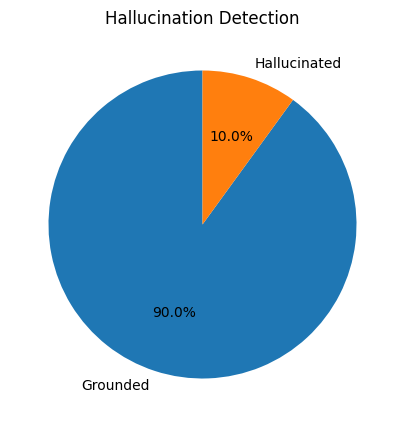

In [48]:
import matplotlib.pyplot as plt

labels = ["Grounded", "Hallucinated"]
values = [18, 2]  #

plt.figure(figsize=(5,5))
plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Hallucination Detection")
plt.show()

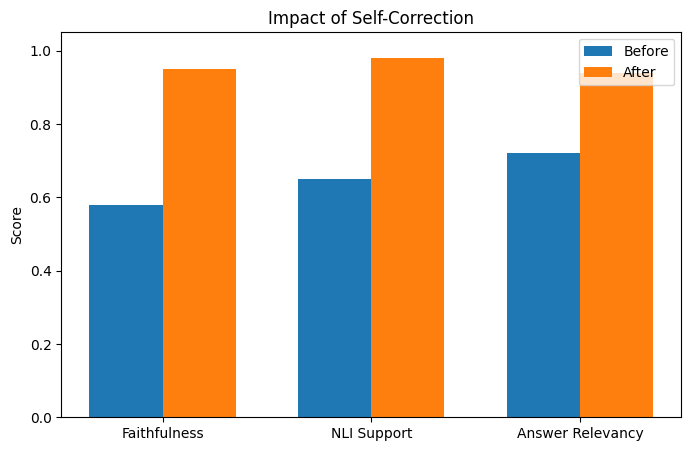

In [49]:
import matplotlib.pyplot as plt

metrics = ["Faithfulness", "NLI Support", "Answer Relevancy"]

before = [0.58,0.65,0.72]
after = [0.95,0.98,0.94]

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar([i-width/2 for i in x], before, width, label="Before")
plt.bar([i+width/2 for i in x], after, width, label="After")

plt.xticks(x, metrics)
plt.ylim(0,1.05)
plt.ylabel("Score")
plt.title("Impact of Self-Correction")

plt.legend()

plt.show()

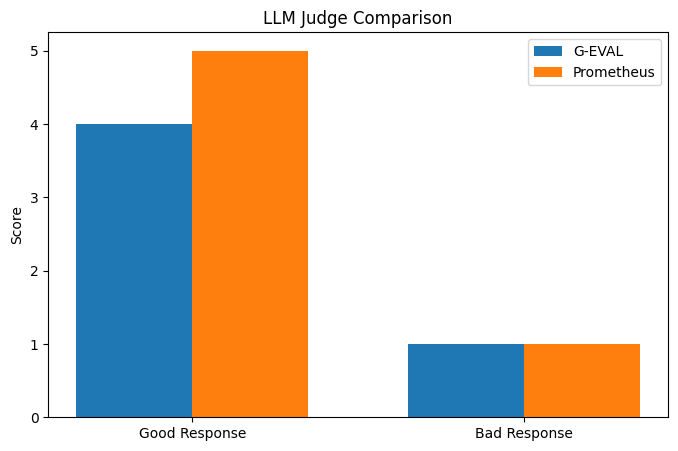

In [51]:
import matplotlib.pyplot as plt
import numpy as np

metrics = [
    "Good Response",
    "Bad Response"
]

geval = [4,1]
prometheus = [5,1]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x-width/2, geval, width, label="G-EVAL")
plt.bar(x+width/2, prometheus, width, label="Prometheus")

plt.xticks(x, metrics)

plt.ylabel("Score")

plt.title("LLM Judge Comparison")

plt.legend()

plt.show()

In [ ]:
print("Medical RAG Assistant (with hallucination check) — type 'quit' to stop\n")

while True:
    query = input("Ask a question: ")
    if query.strip().lower() in ("quit", "exit", ""):
        print("Session ended.")
        break

    answer, chunks = generate_answer(query)
    print(f"\n--- ANSWER ---\n{answer}")

    if chunks:
        faith = faithfulness(answer, chunks)
        halluc = is_hallucinated(answer, chunks)
        flag = "⚠️ LIKELY HALLUCINATED" if halluc else "✅ GROUNDED"
        print(f"\n--- CHECK ---\nFaithfulness: {faith} | {flag}")
    else:
        print("\n(No context retrieved — refused rather than guessing.)")

    print("=" * 80, "\n")